# Импорты библиотек

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd

import os
import urllib.request
import sys

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as f
import torch.optim as optim

import torchvision
from torchvision.transforms import v2
from torchvision import models
from torchvision.models import resnet18, ResNet18_Weights
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import random
from PIL import Image
import matplotlib.pyplot as plt
print(torch.__version__)

2.10.0+cu128


Настройка CUDA для torch. CPU работает сверхмедленно (увы, придётся), но если выйдет запустить блокнот в Google Colab: TPU позволят обучить модель намного быстрее.

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("CUDA is available. Using GPU.")
else:
    device = torch.device('cpu')
    print("CUDA is not available. Using CPU.")

CUDA is available. Using GPU.


# Импорт и первичная подготовка данных

In [5]:
df = pd.read_csv('/content/drive/MyDrive/VKR/multimodal_train.tsv', sep='\t')

В датасете имеется три поля с разметкой: 2_way_label, 3_way_label и 6_way_label. Поскольку работать я выбрал с последним типом разметки, другие столбцы можно отбросить. Также есть поле с очищенным заголовком, поэтому для удобства можно убрать и поле title.

In [6]:
df.drop(['2_way_label', '3_way_label', 'title'], axis = 1, inplace =True)
df.head(10)

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,upvote_ratio,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,0.84,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,0.99,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,0.92,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,0.95,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,0.84,2
5,CrimsonBlue90,bride and groom exchange vows after fatal shoo...,1.423681e+09,independent.ie,True,2vkbtj,https://external-preview.redd.it/FQ-J9OIPFRpqi...,NaN,7.0,6,nottheonion,0.64,0
6,happenpupe,major thermos,1.495660e+09,i.redd.it,True,6d50rl,https://preview.redd.it/l9gvkkf3jizy.jpg?width...,NaN,0.0,2,pareidolia,0.67,2
7,nyswagggggggg,rabbi meat from cloned pig could be kosher for...,1.521729e+09,timesofisrael.com,True,86byl8,https://external-preview.redd.it/KHisCPOGwz7cz...,NaN,577.0,6769,nottheonion,0.92,0
8,ApiContraption,cutouts,1.397145e+09,NaN,True,cgp0lmq,http://i.imgur.com/vbveIEd%2ejpg,22p8pc,NaN,1,psbattle_artwork,NaN,4
9,Charr-the-Chair,jesus christ converting local teens to christi...,1.534787e+09,i.redd.it,True,98vrcq,https://preview.redd.it/31aw9wjucah11.jpg?widt...,NaN,0.0,5,fakehistoryporn,0.79,2


В датасете более 900 тысяч записей, работа с таким количеством займёт невероятные объёмы времени с моими вычислительными ресурсами, поэтому используем train_test_split() чтобы работать с 2% этих записей, получив около 10 тысяч строк.

In [7]:
df, df_backup = train_test_split(
    df,
    test_size = 0.9825,
    shuffle = True,
    stratify = df["6_way_label"]
)

Стратификация применяется для сохранения баланса классов из изначального, полного датасета. То есть в выделенном объёме данных соотношение классов не будет отличаться от полной выборки.

Посмотрим на данные.

In [8]:
df.reset_index(drop = True, inplace = True)
df

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,upvote_ratio,6_way_label
0,theDolphinator25,louis the th is executed,1.561985e+09,i.redd.it,True,c7s5m6,https://preview.redd.it/e24x0w2l4n731.png?widt...,NaN,0.0,94,fakehistoryporn,0.96,2
1,nyran20,cat island felines outnumber humans on japans ...,1.425403e+09,nbcnews.com,True,2xsz8i,https://external-preview.redd.it/b-MeMm2CCYjgD...,NaN,0.0,23,nottheonion,0.90,0
2,Danenel,french soldier excecuted by his superiors in w...,1.535712e+09,i.redd.it,True,9bshfk,https://preview.redd.it/cdqld7uhpej11.jpg?widt...,NaN,1.0,16,fakehistoryporn,0.91,2
3,Meikeetc,my language teachers sort their books by color,1.565980e+09,i.redd.it,True,cragag,https://preview.redd.it/fg3xz62mtug31.jpg?widt...,NaN,5.0,42,mildlyinteresting,0.86,0
4,mbash013,dummy missing his face,1.533661e+09,i.redd.it,True,95dei7,https://preview.redd.it/lbft53v8cpe11.jpg?widt...,NaN,6.0,4,photoshopbattles,0.76,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9865,icyv317,amine fans going too far,1.434400e+09,NaN,True,cs7khto,http://i.imgur.com/4AkNauY.jpg,39wp12,NaN,23,psbattle_artwork,NaN,4
9866,Thaddel,who is a militarist by hofdruckerei hermann be...,1.391282e+09,abload.de,True,1wqtis,https://external-preview.redd.it/WoNXLliN32qCZ...,NaN,31.0,244,propagandaposters,0.97,5
9867,zuluke,puttin on the ritz,1.359508e+09,NaN,True,c85yvyg,http://i.imgur.com/KrdqXV2.jpg,17iy0p,NaN,16,psbattle_artwork,NaN,4
9868,Tel0s,msu student commits random acts of flowers,1.349842e+09,billingsgazette.com,True,118h5m,https://external-preview.redd.it/7vCxgHEXLSe-p...,NaN,0.0,28,upliftingnews,0.90,0


In [9]:
print(df['clean_title'].isnull().sum())
print(df['id'].isnull().sum())
print(df['hasImage'].isnull().sum())

print(df['hasImage'].value_counts())

0
0
0
hasImage
True    9870
Name: count, dtype: int64


<Axes: title={'center': '6_way_label'}, ylabel='Frequency'>

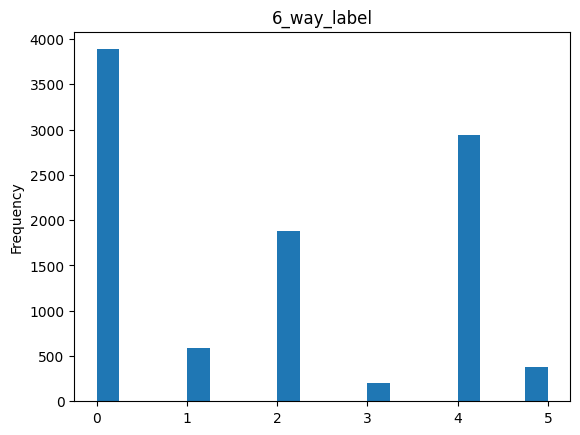

In [10]:
df['6_way_label'].plot(kind = 'hist', bins = 20, title = '6_way_label')

## Загрузка изображений по URL

Важно правильно загрузить изображения и учесть, какие из них загрузить невозможно, чтобы убрать эту запись из выборки. Используем библиотеку urllib.

In [11]:
df = df.replace(np.nan, '', regex = True) #Чтобы не вылезала ошибка по NaN
df.fillna('', inplace = True)
print(df['6_way_label'].value_counts())

6_way_label
0    3886
4    2938
2    1876
1     586
5     378
3     206
Name: count, dtype: int64


In [12]:
import urllib.request
from urllib.error import HTTPError, URLError
import os
import pandas as pd

base_dir = "/content/drive/MyDrive/VKR/images"
if not os.path.exists(base_dir):
    os.makedirs(base_dir)

# Заголовки для разных доменов (работает с полными URL)
def get_headers_for_url(url):
    """Возвращает подходящие headers для конкретного домена"""
    if 'reddit.com' in url or 'redd.it' in url:
        return {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
            'Accept': 'image/webp,image/apng,image/*,*/*;q=0.8',
            'Referer': 'https://www.reddit.com/'
        }
    elif 'imgur.com' in url:
        return {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
            'Accept': 'image/webp,image/apng,image/*,*/*;q=0.8'
        }
    else:
        return {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
            'Accept': 'image/webp,image/apng,image/*,*/*;q=0.8'
        }

print("Начало загрузки изображений...")
indices_to_drop = []
success_count = 0

for index, row in df.iterrows():
    if row["hasImage"] == True and pd.notna(row["image_url"]) and row["image_url"] != "":
        image_url = row["image_url"]
        img_id = row["id"]
        path = os.path.join(base_dir, f"{img_id}.jpg")

        try:
            # Получаем headers для полного URL (без очистки)
            headers = get_headers_for_url(image_url)

            req = urllib.request.Request(image_url, headers=headers)

            # Скачивание с обработкой редиректов
            with urllib.request.urlopen(req, timeout=15) as response:
                data = response.read()

                # Проверка на пустой файл
                if len(data) == 0:
                    indices_to_drop.append(index)
                    continue

                # Запись файла
                with open(path, 'wb') as out_file:
                    out_file.write(data)

                # Проверка размера файла
                if os.path.getsize(path) == 0:
                    os.remove(path)
                    indices_to_drop.append(index)
                else:
                    success_count += 1

        except (HTTPError, URLError, Exception) as e:
            # Обработка ошибок
            indices_to_drop.append(index)
            pass

# Удаление битых записей из DataFrame
if indices_to_drop:
    print(f"Не удалось загрузить {len(indices_to_drop)} изображений. Очистка датасета...")
    df.drop(indices_to_drop, axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)
else:
    print("Все изображения загружены успешно.")

print(f"Успешно загружено: {success_count}")
print('Завершено.')

Начало загрузки изображений...
Не удалось загрузить 429 изображений. Очистка датасета...
Успешно загружено: 9408
Завершено.


Необходимо соблюдать чистоту и релевантность данных, поэтому проведём валидацию. Нам необходимо, чтобы все скачанные изображения открывались. Проверим это, и, в случае неудачи, удалим данную запись из выборки.

In [13]:
def validation(directory, df):
    corrupted = []

    for index, row in df.iterrows():
        img_path = '/content/drive/MyDrive/VKR/images/' + row['id'] + '.jpg'
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append(img_path)
            print(f"Не удалось открыть {img_path}: {e}")
            df.drop(index = index, axis = 0, inplace = True)

    return corrupted

directory = "/content/drive/MyDrive/VKR/images/"
corrupted = validation(directory, df)

Не удалось открыть /content/drive/MyDrive/VKR/images/biphyv.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/VKR/images/biphyv.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/cwo0940.jpg: cannot identify image file '/content/drive/MyDrive/VKR/images/cwo0940.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/cakwaac.jpg: cannot identify image file '/content/drive/MyDrive/VKR/images/cakwaac.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/6uptq3.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/VKR/images/6uptq3.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/cjvjt3.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/VKR/images/cjvjt3.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/d9wy3z.jpg: [Errno 2] No such file or directory: '/content/drive/MyDrive/VKR/images/d9wy3z.jpg'
Не удалось открыть /content/drive/MyDrive/VKR/images/b9eomh.jpg: [Errno 2] No such file or directory: '/content/drive/MyDr

In [14]:
if corrupted:
    print(f"{len(corrupted)} изображений не удалось открыть :(")
else: print('Все изображения рабочие.')
df.reset_index(drop = True, inplace = True)
print("Распределение классов ПОСЛЕ загрузки изображений:")
print(df['6_way_label'].value_counts().sort_index())
print(f"\nВсего записей: {len(df)}")

39 изображений не удалось открыть :(
Распределение классов ПОСЛЕ загрузки изображений:
6_way_label
0    3629
1     550
2    1740
3     203
4    2907
5     373
Name: count, dtype: int64

Всего записей: 9402


Посмотрим на оставшиеся картиночки

(179, 320, 3)


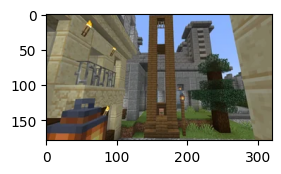

(168, 320, 3)


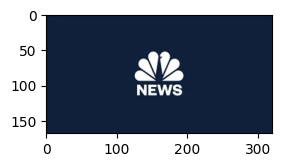

(179, 320, 3)


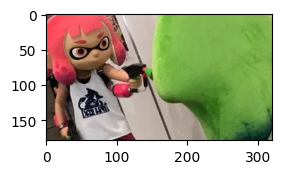

(226, 320, 3)


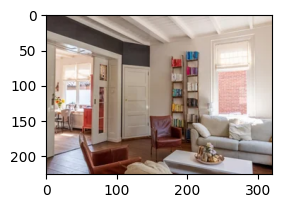

(426, 320, 3)


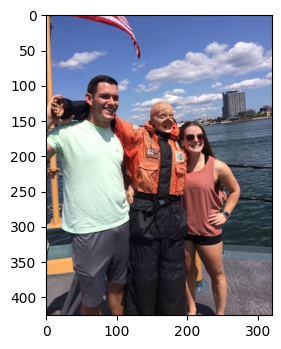

In [15]:
for i in range(5):
    path = '/content/drive/MyDrive/VKR/images/' + df['id'][i] + '.jpg'

    image = np.array(Image.open(path))

    print(image.shape)
    ax = plt.subplot(121)
    ax.imshow(image)
    plt.show()

Для ResNet также важны RGB каналы.

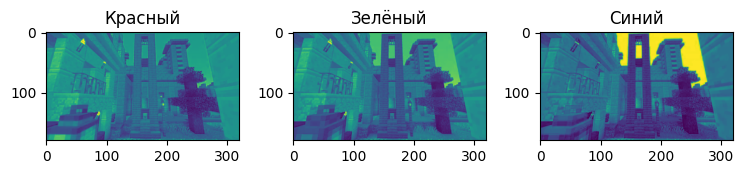

In [16]:
img_path = "/content/drive/MyDrive/VKR/images/" + df['id'][0] + '.jpg'
image = Image.open(img_path).convert('RGB')

r, g, b = image.split()

plt.figure(figsize = (10, 5))

plt.subplot(1, 4, 1)
plt.imshow(r)
plt.title('Красный')

plt.subplot(1, 4, 2)
plt.imshow(g)
plt.title('Зелёный')

plt.subplot(1, 4, 3)
plt.imshow(b)
plt.title('Синий')

plt.tight_layout()
plt.show()

Также важно, что ResNet принимает изображения исключительно в формате (256, 256, 3), значит нам необходимо их подогнать. Для этого можно использовать инструмент из самой библиотеки pytorch.

In [17]:
target_size = (224, 224)
for index, row in df.iterrows():
    img_path = '/content/drive/MyDrive/VKR/images/' + row['id'] + '.jpg'
    img = Image.open(img_path).convert('RGB')

    resize_transform = v2.Resize(target_size)
    resized_img = resize_transform(img)
    resized_img.save(img_path)

(224, 224, 3)


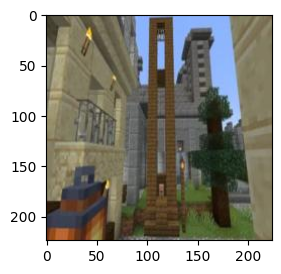

(224, 224, 3)


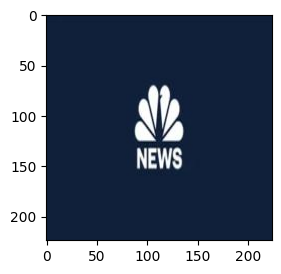

(224, 224, 3)


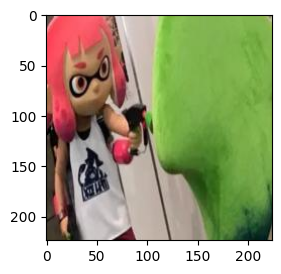

(224, 224, 3)


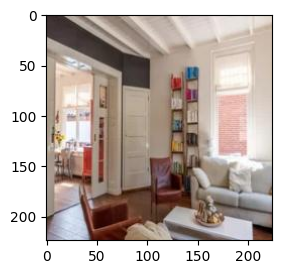

(224, 224, 3)


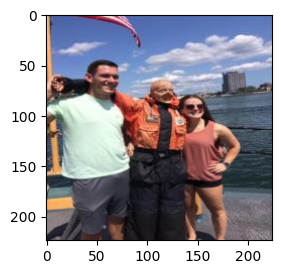

In [18]:
for i in range(5):
    path = '/content/drive/MyDrive/VKR/images/' + df['id'][i] + '.jpg'
    image = np.array(Image.open(path))
    print(image.shape)
    ax = plt.subplot(121)
    ax.imshow(image)
    plt.show()

Стоит сохранить текущую выборку для дальнейшей работы, чтобы не было необходимости каждый раз заново создавать выборку и скачивать изображения.

In [19]:
SAMPLE_CSV_PATH = '/content/drive/MyDrive/VKR/df_sample_2percent.tsv'
df.to_csv(SAMPLE_CSV_PATH, sep='\t', index=False, encoding='utf-8')

## Преднастройка BERT

In [20]:
%%capture


! pip install bert-serving-server  # server-side
! pip install bert-serving-client  # client-side
! pip install torch transformers

In [21]:
import torch
from transformers import DistilBertModel, DistilBertTokenizer

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
bert_model = DistilBertModel.from_pretrained(model_name, output_hidden_states = True)

bert_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [22]:
def get_bert_embedding(text):
    #Токенизируем входной текст и получим ID токенов вместе с маской внимания
    inputs = tokenizer(text, add_special_tokens = True, return_tensors = 'pt', max_length = 80, truncation = True, padding = 'max_length')
    return inputs['input_ids'].squeeze(0), inputs['attention_mask'].squeeze()

text = 'This is an example Reddit submission title.'
input_ids, attention_mask = get_bert_embedding(text)
print(input_ids.shape)
print(attention_mask.shape)


torch.Size([80])
torch.Size([80])


# Загрузка входных данных

In [23]:
df_train, df_test = train_test_split(df, test_size = 0.2, stratify = df['6_way_label'])
df_test, df_val = train_test_split(df_test, test_size = 0.5, stratify = df_test["6_way_label"])

Создадим отдельный класс на основе Dataset из PyTorch. Это нужно для оптимальной работы загрузчика.

In [24]:
class FakedditDataset(Dataset):
    def __init__(self,
                 df,
                 text_field = 'clean_title',
                 label_field = '6_way_label',
                 image_id = 'id'):
        self.df = df.reset_index(drop = True)
        self.text_field = text_field
        self.label_field = label_field
        self.image_id = image_id
        self.img_size = 224
        """
        Нормализуем изображения, используя рекомендуемые ImageNet параметры среднего и отклонения
        """
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]
        self.transform_f = v2.Compose(
            [ v2.Resize(224),
              v2.ToImage(),
              v2.ToDtype(torch.float32, scale = True),
              v2.Normalize(self.mean, self.std)
            ])


    def __getitem__(self, index):
        text = str(self.df.at[index, self.text_field])
        label = self.df.at[index, self.label_field]
        img_path = "/content/drive/MyDrive/VKR/images/" + self.df.at[index, self.image_id] + '.jpg'
        image = Image.open(img_path)
        img = self.transform_f(image)
        input_ids, attention_mask = get_bert_embedding(text)

        return input_ids, attention_mask, label, img


    def __len__(self):
        return self.df.shape[0]

In [25]:
train_dataset = FakedditDataset(df_train)
test_dataset = FakedditDataset(df_test)
validation_dataset = FakedditDataset(df_val)

In [26]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = True)
validation_loader = DataLoader(validation_dataset, batch_size = 16, shuffle = True)

print(len(train_loader))

input_ids, attention_mask, label, img = next(iter(train_loader))
print(input_ids.shape, attention_mask.shape, label.shape, img.shape)

471
torch.Size([16, 80]) torch.Size([16, 80]) torch.Size([16]) torch.Size([16, 3, 224, 224])


# Разработка модели

Мультимодальная модель использует BERT Base для обработки текста и ResNet50 для обработки изображений.

In [27]:
class MultimodalClassifierBERTResNet(nn.Module):
    def __init__(self, num_classes = 6):

        super(MultimodalClassifierBERTResNet, self).__init__()

        self.num_classes = num_classes

        self.image_model = resnet18(weights = ResNet18_Weights.IMAGENET1K_V1)
        self.fc_image = nn.Linear(in_features=1000, out_features=num_classes, bias=True)
        self.drop = nn.Dropout(p = 0.3)

        self.text_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.fc_text = nn.Linear(in_features = self.text_model.config.hidden_size, out_features = num_classes, bias = True)

        #Слияние
        self.softmax = nn.Softmax(dim = 1)

    def forward(self, image, text_input_ids, text_attention_mask, ):
        x_img = self.image_model(image)
        x_img = self.drop(x_img)
        x_img = self.fc_image(x_img)

        x_text_last_hidden_states = self.text_model(
            input_ids = text_input_ids,
            attention_mask = text_attention_mask,
            return_dict=False
        )
        x_text_pooled_output = x_text_last_hidden_states[0][:, 0, :]
        x_text = self.drop(x_text_pooled_output)
        x_text = self.fc_text(x_text_pooled_output)

        x = torch.max(x_text, x_img)

        return x

## Подготовим обучение и оценку модели

Перво-наперво, регулярная практика — механизм EarlyStopping. Он произведёт остановку модели в случае, когда в течение определённого количества эпох модель не улучшается. Это экономит кучу времени при обучении.

In [28]:
class EarlyStopping:
    def __init__(self, patience = 4, verbose = False, delta = 0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.delta = delta


    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"ES counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

Теперь очередь функции потерь и оптимизатора. Оптимизатор будет использован Adam, функция потерь — CrossEntropyLoss.

In [29]:
model = MultimodalClassifierBERTResNet(num_classes = 6)
model = model.to(device)

labels = df_train['6_way_label'].to_numpy()
unique_classes = np.unique(labels)

print(f"Уникальные классы в training set: {unique_classes}")
print(f"Количество классов: {len(unique_classes)}")
class_weights = compute_class_weight(class_weight = 'balanced',
                                     classes = np.unique(labels),
                                     y = labels)
class_weights = torch.tensor(class_weights, dtype = torch.float).to(device)



criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-5)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer,
                                          min_lr = 1e-6,
                                          factor = 0.5,
                                          patience = 1,
                                          #verbose = True)
                                          )
num_epochs = 20

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Уникальные классы в training set: [0 1 2 3 4 5]
Количество классов: 6


In [30]:

def train_model(model, train_loader, validation_loader, criterion, optimizer, scheduler, num_epochs):
    """
    Обучение модели с сохранением всех метрик по каждой эпохе.
    """
    early_stopping = EarlyStopping(patience=5, verbose=True)


    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'accuracy': [],
        'precision_weighted': [],
        'recall_weighted': [],
        'f1_weighted': []
    }

    # Добавляем колонки для метрик по каждому классу (6 классов)
    class_names = ['TRUE', 'SATIRE', 'FALSE_CONN', 'IMPOSTER', 'MANIPULATED', 'MISLEADING']
    for name in class_names:
        history[f'precision_{name}'] = []
        history[f'recall_{name}'] = []
        history[f'f1_{name}'] = []

    for epoch in range(num_epochs):
        print(f'\n{"="*80}')
        print(f'ЭПОХА {epoch + 1}/{num_epochs}')
        print(f'{"="*80}')


        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, label, img in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            label = label.to(device)
            img = img.to(device)

            optimizer.zero_grad()
            outputs = model(img, input_ids, attention_mask)
            loss = criterion(outputs, label)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * img.size(0)

        train_loss = running_loss / len(train_loader.dataset)


        model.eval()
        val_metrics = evaluate_model(model, validation_loader, criterion, class_names)

        # Сохраняем метрики в историю
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['val_loss'])
        history['accuracy'].append(val_metrics['accuracy'])
        history['precision_weighted'].append(val_metrics['precision_weighted'])
        history['recall_weighted'].append(val_metrics['recall_weighted'])
        history['f1_weighted'].append(val_metrics['f1_weighted'])

        # Метрики по классам
        for i, name in enumerate(class_names):
            history[f'precision_{name}'].append(val_metrics['precision_per_class'][i])
            history[f'recall_{name}'].append(val_metrics['recall_per_class'][i])
            history[f'f1_{name}'].append(val_metrics['f1_per_class'][i])

        # Планировщик и ранняя остановка
        scheduler.step(val_metrics['val_loss'])
        early_stopping(val_metrics['val_loss'])

        if early_stopping.early_stop:
            print("\n!!! Early Stopping triggered !!!")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv('training_history.csv', index=False, encoding='utf-8')
    print(f"\n{'='*80}")
    print(f"История обучения сохранена в 'training_history.csv'")
    print(f'{'='*80}')


    print(f"\n{'='*80}")
    print(f"ТАБЛИЦА МЕТРИК ПО ЭПОХАМ (для ВКР)")
    print(f'{'='*80}')


    display_cols = ['epoch', 'train_loss', 'val_loss', 'accuracy', 'f1_weighted']
    print(history_df[display_cols].to_string(index=False))
    print(f'{'='*80}')


    plt.figure(figsize=(12, 6))
    plt.plot(history['epoch'], history['f1_weighted'], 'b-o', label='F1 (weighted)', linewidth=2)
    plt.plot(history['epoch'], history['accuracy'], 'g-s', label='Accuracy', linewidth=2)
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Метрика', fontsize=12)
    plt.title('Динамика метрик качества в процессе обучения', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig('metrics_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    return history_df

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, test_loader, criterion, class_names=None):
    """
    Оценка модели с расчётом метрик по каждому классу отдельно.
    """
    if class_names is None:
        class_names = ['TRUE', 'SATIRE', 'FALSE_CONN', 'IMPOSTER', 'MANIPULATED', 'MISLEADING']

    model.eval()
    val_losses = []
    correct_preds = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, label, img in test_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            label = label.to(device)
            img = img.to(device)

            outputs = model(
                image=img,
                text_input_ids=input_ids,
                text_attention_mask=attention_mask
            )

            _, preds = torch.max(outputs, dim=1)

            val_loss = criterion(outputs, label)

            correct_preds += torch.sum(preds == label).item()
            total_samples += label.size(0)

            val_losses.append(val_loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())


    accuracy = float((correct_preds / total_samples) * 100)
    precision_weighted = precision_score(all_labels, all_preds, average='weighted')
    recall_weighted = recall_score(all_labels, all_preds, average='weighted')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    precision_per_class = precision_score(all_labels, all_preds, average=None, labels=range(6))
    recall_per_class = recall_score(all_labels, all_preds, average=None, labels=range(6))
    f1_per_class = f1_score(all_labels, all_preds, average=None, labels=range(6))

    print('=' * 80)
    print('ОБЩИЕ МЕТРИКИ')
    print('=' * 80)
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision (weighted): {precision_weighted:.4f}')
    print(f'Recall (weighted): {recall_weighted:.4f}')
    print(f'F1-Score (weighted): {f1_weighted:.4f}')
    print('=' * 80)
    print('МЕТРИКИ ПО КЛАССАМ')
    print('=' * 80)
    print(f'{"Класс":<15} {"Precision":<12} {"Recall":<12} {"F1":<12}')
    print('-' * 50)
    for i, name in enumerate(class_names):
        print(f'{name:<15} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f}')
    print('=' * 80)


    return {
        'accuracy': accuracy,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'val_loss': np.mean(val_losses)
    }


ЭПОХА 1/20
ОБЩИЕ МЕТРИКИ
Accuracy: 60.36%
Precision (weighted): 0.6689
Recall (weighted): 0.6036
F1-Score (weighted): 0.6232
МЕТРИКИ ПО КЛАССАМ
Класс           Precision    Recall       F1          
--------------------------------------------------
TRUE            0.7425       0.7466       0.7445      
SATIRE          0.2600       0.4727       0.3355      
FALSE_CONN      0.4167       0.3736       0.3939      
IMPOSTER        0.1270       0.4000       0.1928      
MANIPULATED     0.8731       0.5911       0.7049      
MISLEADING      0.4333       0.6842       0.5306      

ЭПОХА 2/20
ОБЩИЕ МЕТРИКИ
Accuracy: 68.86%
Precision (weighted): 0.7113
Recall (weighted): 0.6886
F1-Score (weighted): 0.6960
МЕТРИКИ ПО КЛАССАМ
Класс           Precision    Recall       F1          
--------------------------------------------------
TRUE            0.8251       0.6887       0.7508      
SATIRE          0.4032       0.4545       0.4274      
FALSE_CONN      0.5103       0.5690       0.5380      
IMP

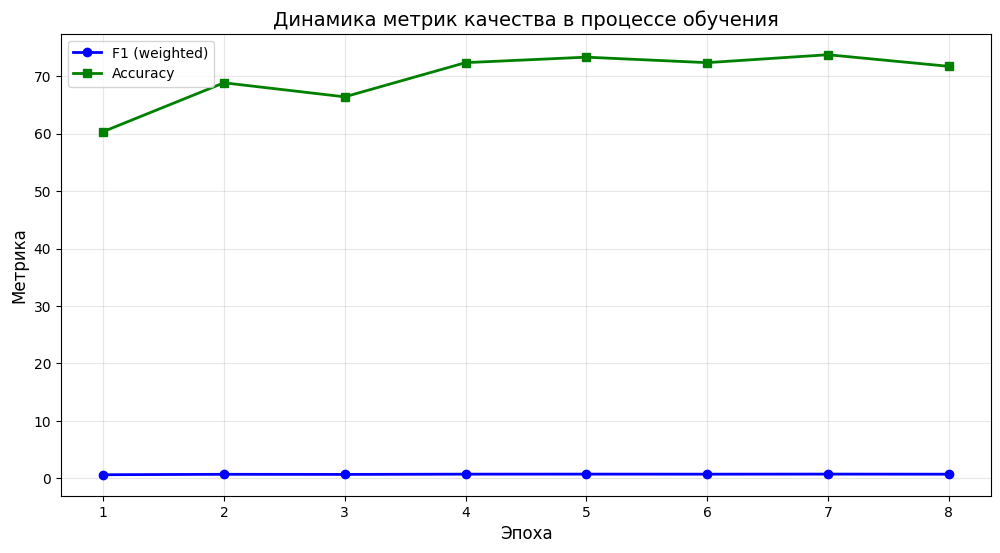

,epoch,train_loss,val_loss,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_TRUE,recall_TRUE,f1_TRUE,...,f1_FALSE_CONN,precision_IMPOSTER,recall_IMPOSTER,f1_IMPOSTER,precision_MANIPULATED,recall_MANIPULATED,f1_MANIPULATED,precision_MISLEADING,recall_MISLEADING,f1_MISLEADING
0,1,1.426398,1.159127,60.361318,0.668855,0.603613,0.623169,0.742466,0.746556,0.744505,...,0.393939,0.126984,0.40,0.192771,0.873096,0.591065,0.704918,0.433333,0.684211,0.530612
1,2,0.937905,0.998275,68.862912,0.711291,0.688629,0.696026,0.825083,0.688705,0.750751,...,0.538043,0.277778,0.50,0.357143,0.797297,0.810997,0.804089,0.560000,0.736842,0.636364
2,3,0.637895,0.987664,66.418704,0.710335,0.664187,0.676691,0.843636,0.639118,0.727273,...,0.543284,0.212766,0.50,0.298507,0.774086,0.800687,0.787162,0.426667,0.842105,0.566372
3,4,0.434315,1.108265,72.369819,0.722728,0.723698,0.721874,0.798319,0.785124,0.791667,...,0.574074,0.333333,0.25,0.285714,0.779935,0.828179,0.803333,0.666667,0.736842,0.700000
4,5,0.303924,1.343761,73.326249,0.728827,0.733262,0.728288,0.798343,0.796143,0.797241,...,0.597015,0.500000,0.15,0.230769,0.789644,0.838488,0.813333,0.583333,0.736842,0.651163
5,6,0.210616,1.418143,72.369819,0.716361,0.723698,0.718727,0.765306,0.826446,0.794702,...,0.576369,0.333333,0.20,0.250000,0.807018,0.790378,0.798611,0.702703,0.684211,0.693333
6,7,0.166918,1.529146,73.751328,0.728636,0.737513,0.731238,0.769036,0.834711,0.800528,...,0.585075,0.333333,0.20,0.250000,0.806667,0.831615,0.818951,0.833333,0.657895,0.735294
7,8,0.132266,1.496965,71.732200,0.712631,0.717322,0.714302,0.765013,0.807163,0.785523,...,0.571429,0.266667,0.20,0.228571,0.822064,0.793814,0.807692,0.658537,0.710526,0.683544


In [32]:
train_model(model, train_loader, validation_loader, criterion, optimizer, scheduler, num_epochs)

In [33]:
evaluate_model(model, test_loader, criterion)

ОБЩИЕ МЕТРИКИ
Accuracy: 72.98%
Precision (weighted): 0.7250
Recall (weighted): 0.7298
F1-Score (weighted): 0.7255
МЕТРИКИ ПО КЛАССАМ
Класс           Precision    Recall       F1          
--------------------------------------------------
TRUE            0.7692       0.8264       0.7968      
SATIRE          0.5135       0.3455       0.4130      
FALSE_CONN      0.5787       0.5920       0.5852      
IMPOSTER        0.6429       0.4286       0.5143      
MANIPULATED     0.8099       0.7931       0.8014      
MISLEADING      0.6757       0.6757       0.6757      


{'accuracy': 72.97872340425532,
 'precision_weighted': 0.7250197453851243,
 'recall_weighted': 0.7297872340425532,
 'f1_weighted': 0.725525687055328,
 'precision_per_class': array([0.76923077, 0.51351351, 0.57865169, 0.64285714, 0.80985915,
        0.67567568]),
 'recall_per_class': array([0.82644628, 0.34545455, 0.59195402, 0.42857143, 0.79310345,
        0.67567568]),
 'f1_per_class': array([0.79681275, 0.41304348, 0.58522727, 0.51428571, 0.80139373,
        0.67567568]),
 'val_loss': np.float64(1.426882462986445)}

In [34]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

def plot_roc_curves(model, test_loader, num_classes=6):
    """
    Построение ROC-кривых для многоклассовой классификации (One-vs-Rest).
    """
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, label, img in test_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            label = label.to(device)
            img = img.to(device)

            outputs = model(image=img, text_input_ids=input_ids, text_attention_mask=attention_mask)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(label.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.hstack(all_labels)

    # One-hot encoding для меток
    labels_onehot = np.zeros((all_labels.size, num_classes))
    labels_onehot[np.arange(all_labels.size), all_labels.astype(int)] = 1

    # Построение кривых
    plt.figure(figsize=(12, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    class_names = ['TRUE', 'SATIRE', 'FALSE_CONN', 'IMPOSTER', 'MANIPULATED', 'MISLEADING']

    aucs = []
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guess')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves (One-vs-Rest)', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Средний AUC (macro): {np.mean(aucs):.4f}")
    return np.mean(aucs)

In [35]:
def show_prediction_examples(model, df, dataset, num_examples=10):
    """
    Визуализация примеров работы классификатора.
    Показывает изображение, заголовок, истинный и предсказанный класс.
    """
    model.eval()
    class_names = ['TRUE', 'SATIRE', 'FALSE_CONN', 'IMPOSTER', 'MANIPULATED', 'MISLEADING']

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    # Берём случайные индексы из датасета
    indices = np.random.choice(len(dataset), num_examples, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            input_ids, attention_mask, label, img = dataset[idx]

            # Добавляем batch dimension
            input_ids = input_ids.unsqueeze(0).to(device)
            attention_mask = attention_mask.unsqueeze(0).to(device)
            img = img.unsqueeze(0).to(device)

            outputs = model(image=img, text_input_ids=input_ids, text_attention_mask=attention_mask)
            _, pred = torch.max(outputs, dim=1)

            # Получаем текст из DataFrame
            text = df.iloc[idx]['clean_title']
            true_label = class_names[label]
            pred_label = class_names[pred.item()]

            # Отображение
            img_np = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
            img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_np = np.clip(img_np, 0, 1)

            axes[i].imshow(img_np)
            axes[i].axis('off')

            # Цвет заголовка: зелёный если верно, красный если ошибка
            color = 'green' if true_label == pred_label else 'red'
            title = f'True: {true_label}\nPred: {pred_label}'
            axes[i].set_title(title, color=color, fontsize=11, fontweight='bold')

            # Подпись с текстом (обрезанным)
            text_short = text[:60] + '...' if len(text) > 60 else text
            axes[i].text(0.5, -0.5, f'"{text_short}"', transform=axes[i].transAxes,
                        fontsize=12, ha='center', style='italic')

    plt.tight_layout()
    plt.savefig('prediction_examples.png', dpi=300, bbox_inches='tight')
    plt.show()

In [36]:
def analyze_errors(model, test_loader, dataset, df, max_errors=10):
    """
    Анализ и визуализация ошибочных предсказаний модели.
    """
    model.eval()
    class_names = ['TRUE', 'SATIRE', 'FALSE_CONN', 'IMPOSTER', 'MANIPULATED', 'MISLEADING']

    errors = []

    with torch.no_grad():
        for batch_idx, (input_ids, attention_mask, label, img) in enumerate(test_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            label = label.to(device)
            img = img.to(device)

            outputs = model(image=img, text_input_ids=input_ids, text_attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)

            # Находим ошибки в батче
            for i in range(len(label)):
                if preds[i] != label[i]:
                    errors.append({
                        'index': batch_idx * test_loader.batch_size + i,
                        'true_label': label[i].item(),
                        'pred_label': preds[i].item(),
                        'image': img[i].cpu(),
                        'input_ids': input_ids[i].cpu(),
                        'attention_mask': attention_mask[i].cpu()
                    })

            if len(errors) >= max_errors:
                break

    print(f"Найдено ошибок: {len(errors)}")

    if len(errors) == 0:
        print("Ошибок не найдено (модель идеальна на этой выборке)!")
        return

    # Визуализация первых 10 ошибок
    num_show = min(10, len(errors))
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    axes = axes.flatten()

    for i, err in enumerate(errors[:num_show]):
        idx = err['index']

        # Декодим изображение
        img_np = err['image'].permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        axes[i].imshow(img_np)
        axes[i].axis('off')

        true_name = class_names[err['true_label']]
        pred_name = class_names[err['pred_label']]

        title = f'True: {true_name}\nPred: {pred_name}'
        axes[i].set_title(title, color='red', fontsize=11, fontweight='bold')

        # Получаем текст
        try:
            text = df.iloc[idx]['clean_title']
            text_short = text[:60] + '...' if len(text) > 60 else text
            axes[i].text(0.5, -0.75, f'"{text_short}"', transform=axes[i].transAxes,
                        fontsize=12, ha='center', style='italic')
        except:
            axes[i].text(0.5, -0.75, 'Текст недоступен', transform=axes[i].transAxes,
                        fontsize=12, ha='center')

    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Статистика ошибок
    error_df = pd.DataFrame(errors)
    error_matrix = pd.crosstab(
        [class_names[e] for e in error_df['true_label']],
        [class_names[e] for e in error_df['pred_label']]
    )
    print("\nМатрица ошибок (True vs Predicted):")
    print(error_matrix)

    return errors

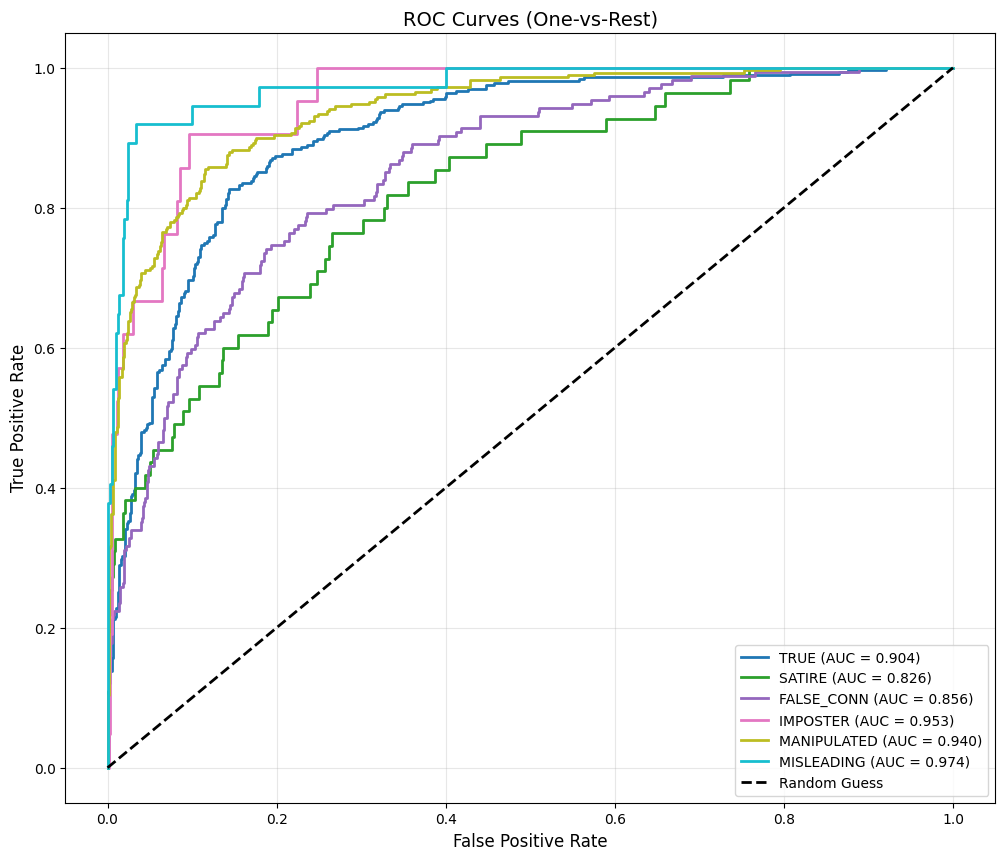

Средний AUC (macro): 0.9087


np.float64(0.908665042490269)

In [41]:
plot_roc_curves(model, test_loader)

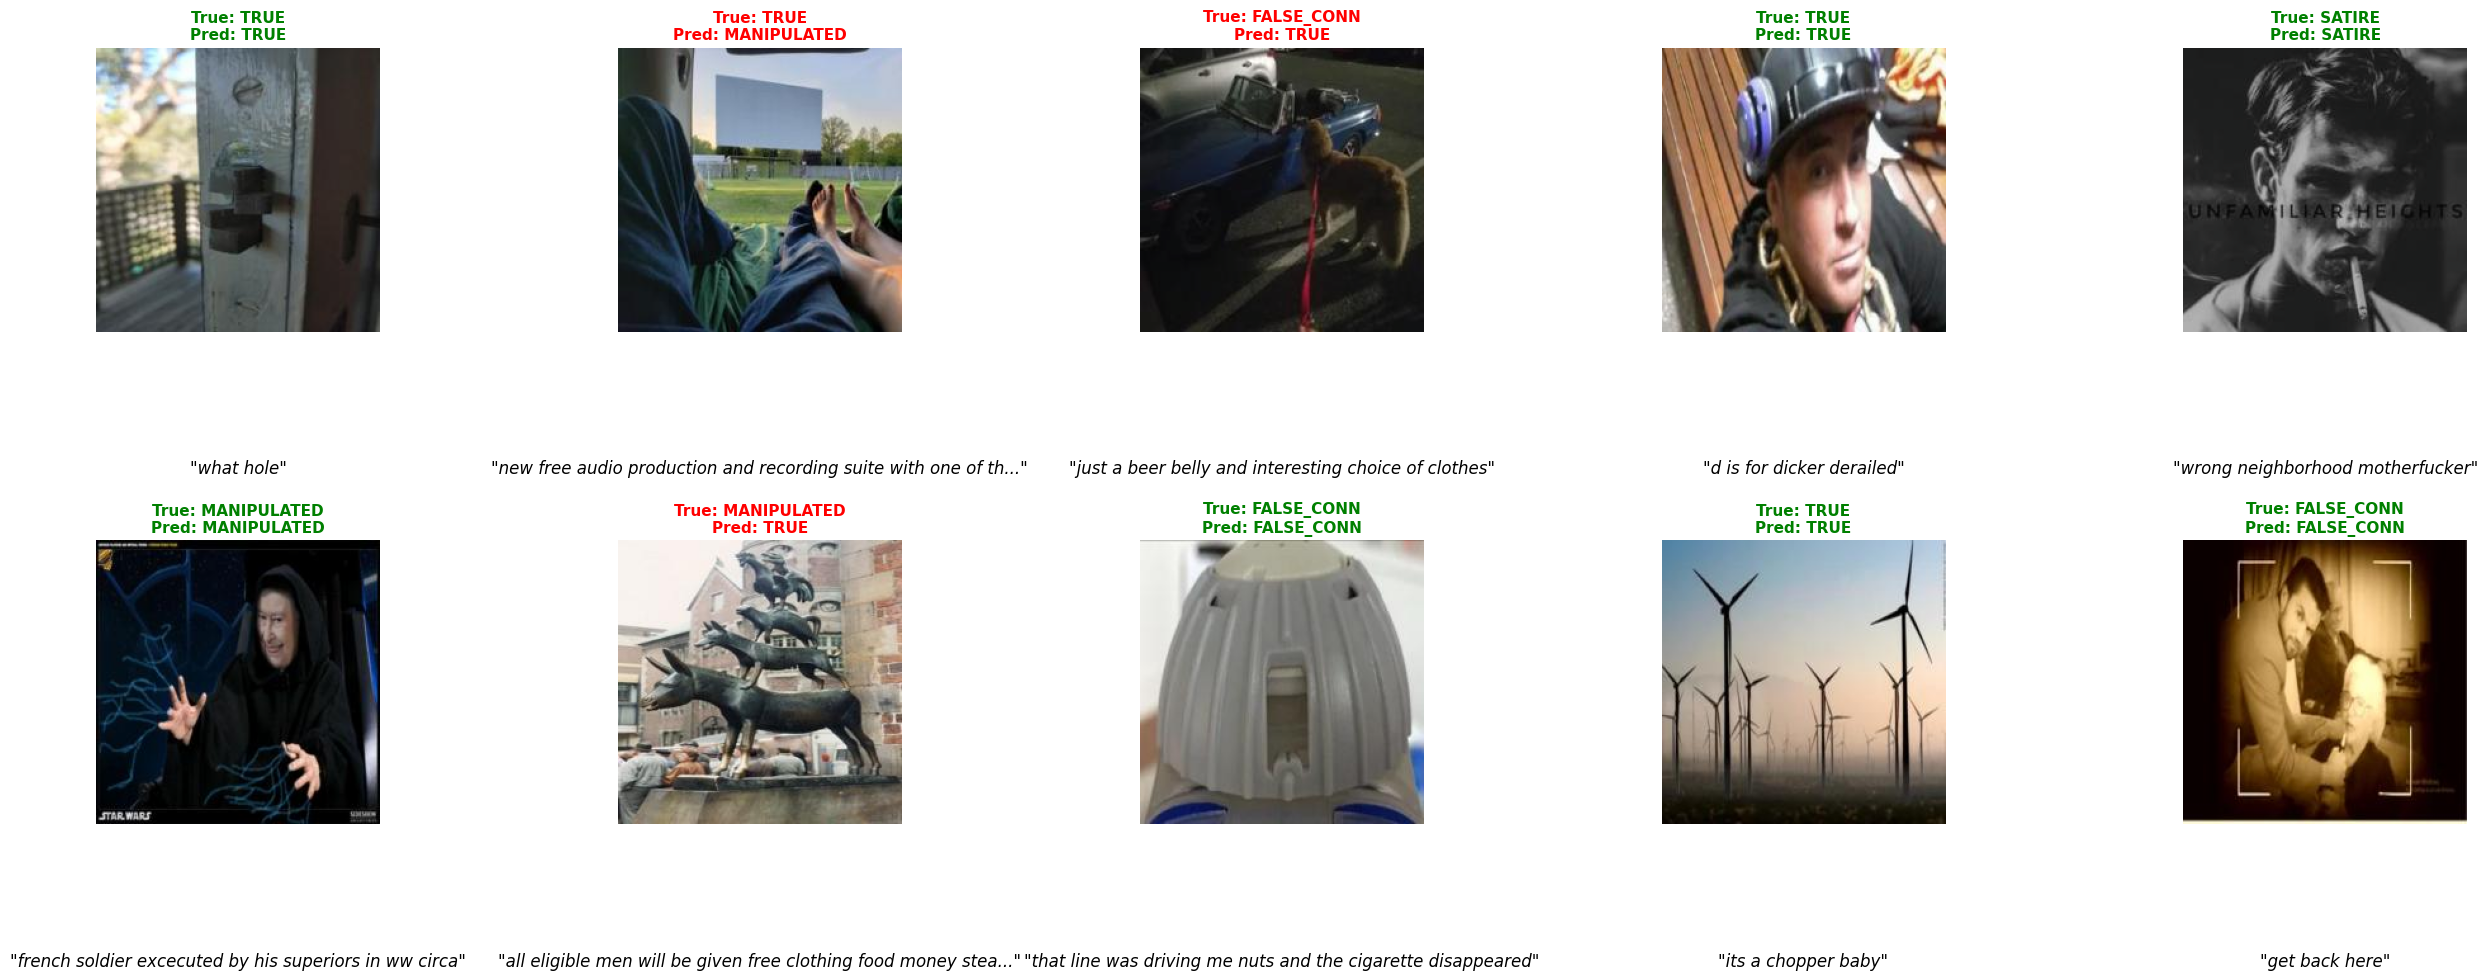

In [38]:
show_prediction_examples(model, df, test_dataset, num_examples=10)

Найдено ошибок: 11


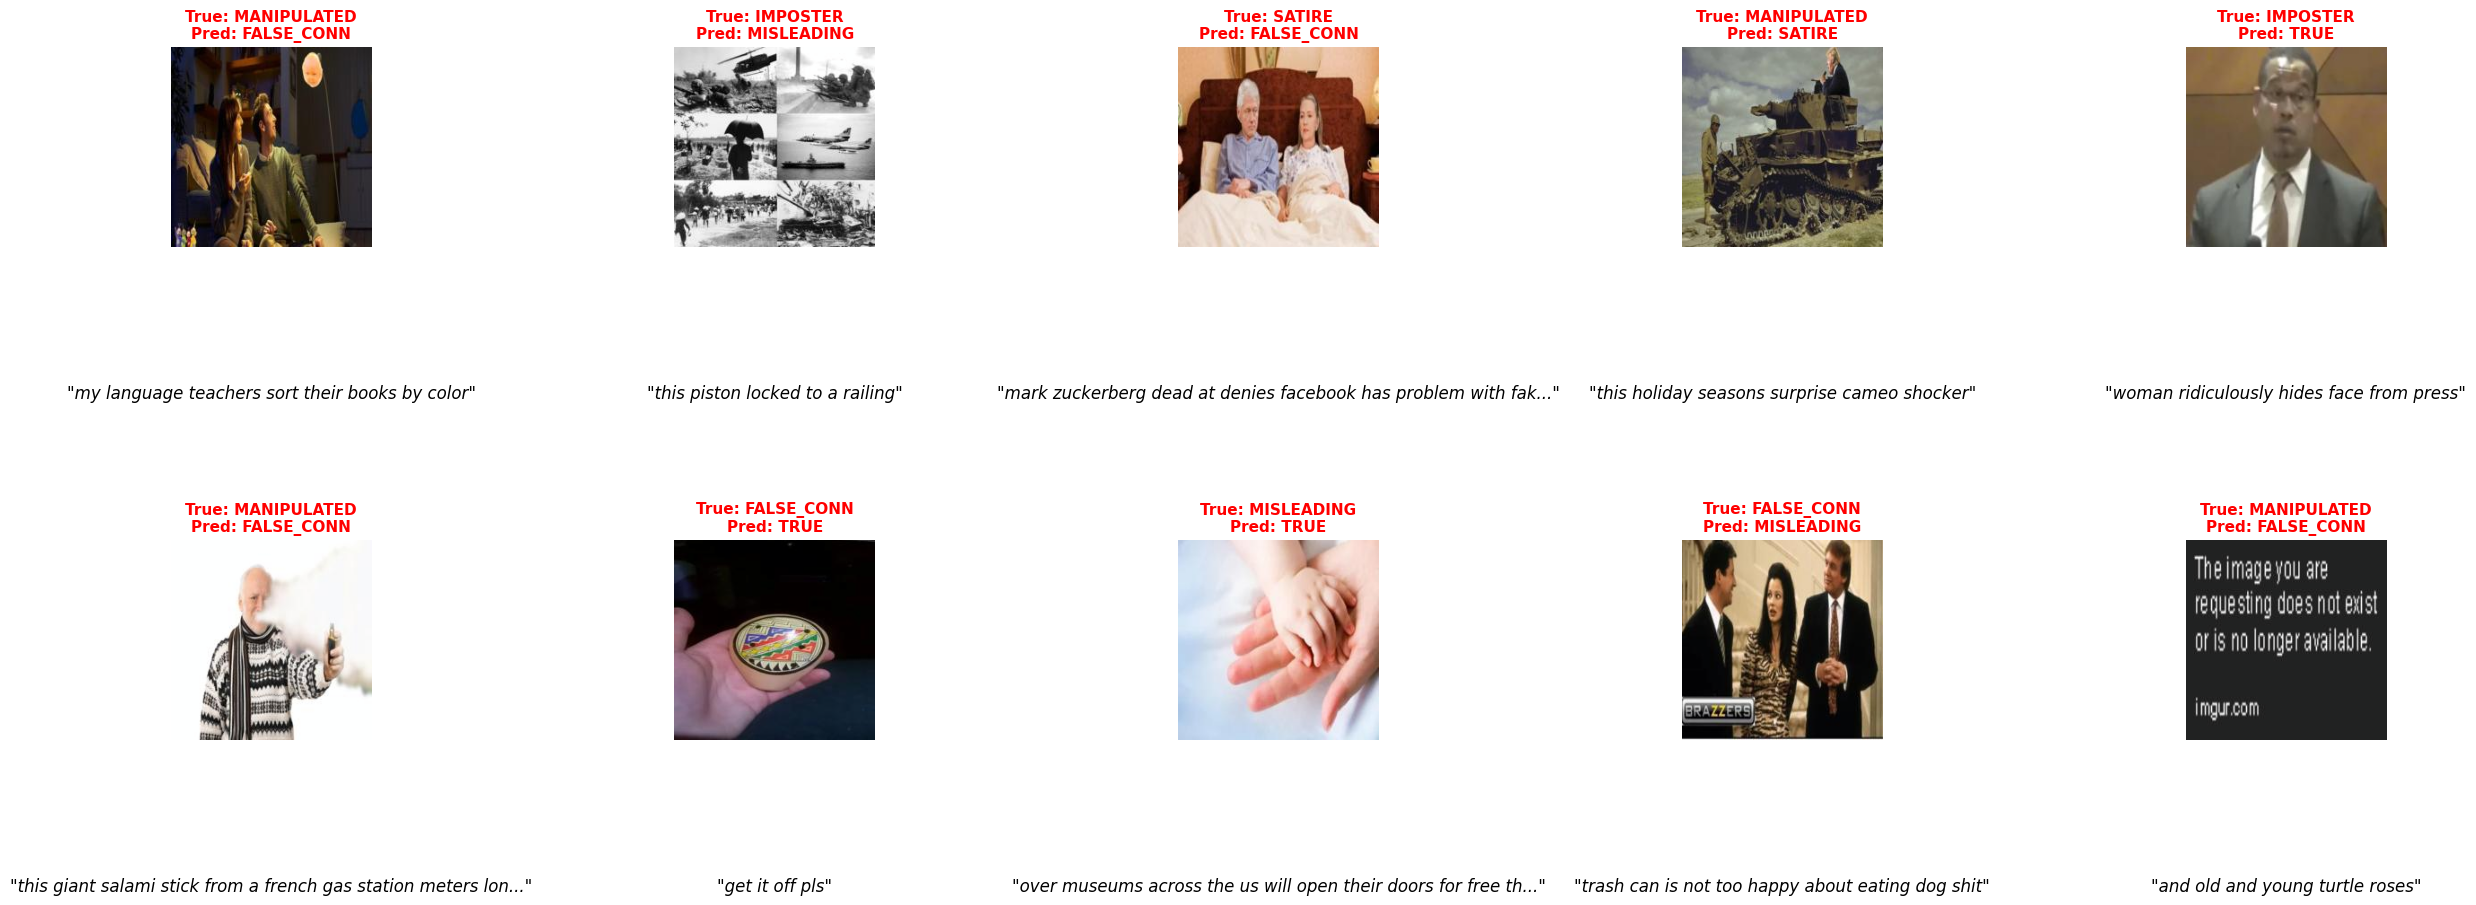


Матрица ошибок (True vs Predicted):
col_0        FALSE_CONN  MISLEADING  SATIRE  TRUE
row_0                                            
FALSE_CONN            0           1       0     2
IMPOSTER              0           1       0     1
MANIPULATED           3           0       1     0
MISLEADING            0           0       0     1
SATIRE                1           0       0     0


[{'index': 3,
  'true_label': 4,
  'pred_label': 2,
  'image': tensor([[[-2.1179, -1.9467, -1.7925,  ..., -1.4672, -1.4672, -1.4500],
           [-2.1179, -1.8782, -1.6898,  ..., -1.4672, -1.4672, -1.4500],
           [-2.0665, -1.8610, -1.6384,  ..., -1.4672, -1.4672, -1.4500],
           ...,
           [-2.1008, -2.0665, -2.0665,  ..., -1.3644, -1.3815, -1.3987],
           [-2.1179, -2.0323, -2.0323,  ..., -1.3473, -1.3644, -1.3644],
           [-2.1179, -2.0665, -1.9809,  ..., -1.3473, -1.3473, -1.3644]],
  
          [[-2.0357, -1.7381, -1.5980,  ..., -1.4055, -1.4055, -1.3880],
           [-1.9482, -1.6681, -1.4930,  ..., -1.4055, -1.4055, -1.3880],
           [-1.8606, -1.6506, -1.4405,  ..., -1.4055, -1.4055, -1.3880],
           ...,
           [-1.9482, -1.8957, -1.9132,  ..., -1.3880, -1.4055, -1.4230],
           [-1.9657, -1.8606, -1.8782,  ..., -1.4055, -1.4230, -1.4230],
           [-2.0182, -1.8606, -1.8256,  ..., -1.4055, -1.4055, -1.4230]],
  
          [[-1.4907, -1

In [39]:
analyze_errors(model, test_loader, test_dataset, df, max_errors=10)